# 1. Подключение библиотек и выгрузка данных из БД

Проводим сплитование пользователей ленты новостей алгоритмом "хэширование с солью", оцениваем корректность системы и работы статистического критерия.

In [ ]:
import pandas as pd
import numpy as np
import pandahouse as ph
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
from scipy.stats import levene
from scipy.stats import ttest_ind
import hashlib

In [ ]:
connection = {'host': 'https://clickhouse',
'database':'',
'user':'',
'password':''
}

Выгружаем пользователей, лайки, просмотры. Основная метрика, по которой будем проводить А/A тест - CTR(likes/views).

In [ ]:
query = '''
select user_id,
countIf(action = 'view') as views,
countIf(action = 'like') as likes,
likes/views as CTR
from {db}.feed_actions
where toDate(time) between '2025-08-26' and '2025-09-01'
group by user_id
'''

In [ ]:
df = ph.read_clickhouse(query, connection=connection)

In [ ]:
df

,user_id,views,likes,CTR
0,13289,32,2,0.062500
1,121096,57,12,0.210526
2,5090,14,2,0.142857
3,129283,80,23,0.287500
4,4394,54,25,0.462963
...,...,...,...,...
41992,3795,17,3,0.176471
41993,123954,101,23,0.227723
41994,124666,141,32,0.226950
41995,11280,133,29,0.218045


# 2. Сплитование пользователей

Напишем функцию "хэширование с солью" для случайного сплитования пользователей.

In [ ]:
def user_split(id, salt='exp_mess_1', n_groups=2):
    test_id = str(id) + '-' + str(salt)
    test_id_digest = hashlib.md5(test_id.encode('ascii')).hexdigest()
    test_id_final_int = int(test_id_digest, 16)
    return test_id_final_int % n_groups

In [ ]:
df['hash_group']=df.user_id.apply(user_split)

In [ ]:
df['hash_group'].value_counts() # проверим, как разбились пользователи, видим, что поровну

hash_group
1    21020
0    20977
Name: count, dtype: int64

<Axes: >

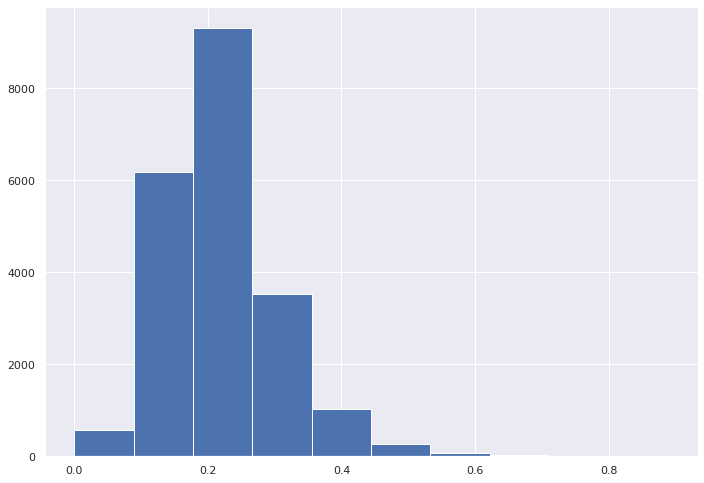

In [ ]:
df[df['hash_group'] == 0]['CTR'].hist()

<Axes: >

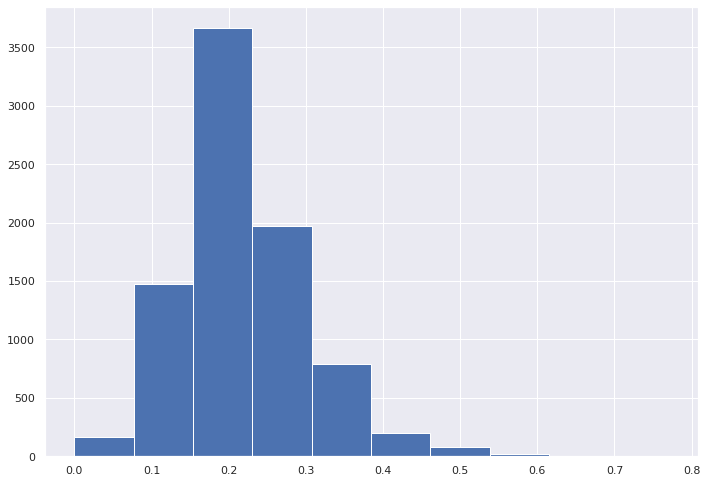

In [ ]:
df[df['hash_group'] == 1]['CTR'].hist()

Посчитаем дисперсии в сплитованных группах и посмотрим на нормальность распределения

In [ ]:
t1 = df[df['hash_group'] == 0]['CTR'].var()
t2 = df[df['hash_group'] == 1]['CTR'].var()

In [ ]:
t1, t2

(0.00692290353315253, 0.006814075075897126)

In [ ]:
ctr1 = df[df['hash_group'] == 0]['CTR']
ctr2 = df[df['hash_group'] == 1]['CTR']
stat, p = levene(ctr1, ctr2)
print("Levene test statistic:", stat, "p-value:", p)

Levene test statistic: 0.09578390140113864 p-value: 0.7569505483925875 # дисперсии одинаковые, что видно из посчитанных значений и теста Левена

Проверим нормальность распределений для сплитованных групп

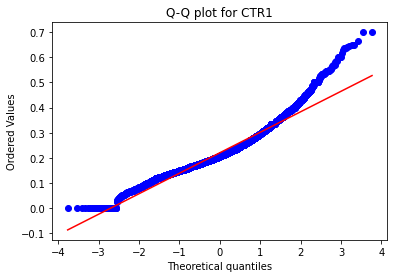

In [ ]:
stats.probplot(ctr1, dist="norm", plot=plt)
plt.title("Q-Q plot for CTR1")
plt.show()

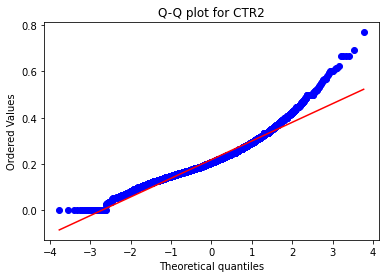

In [ ]:
stats.probplot(ctr2, dist="norm", plot=plt)
plt.title("Q-Q plot for CTR2")
plt.show()

Видно, что распределения не нормальные, вместе с тем размер выборки позволяет применять t-test

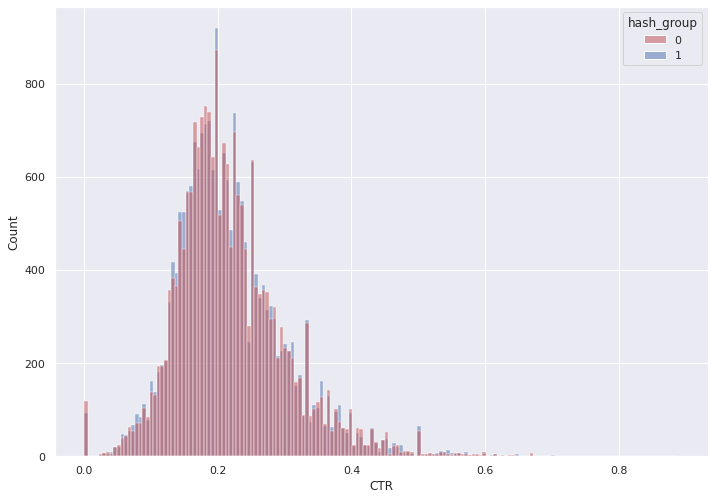

In [ ]:
sns.set(rc={'figure.figsize':(11.7,8.27)})

groups = sns.histplot(data = df,
              x='CTR',
              hue='hash_group',
              palette = ['r', 'b'],
              alpha=0.5,
              kde=False)

Видно, что гистограммы распределений накладываются друг на друга, что косвенно подтверждает правильность системы сплитования

# 3. Проведение А/А-теста

Запускаем цикл расчета p-value через t-test. Для выбора случайных значений сэмплируем из наших групп выборки по 500 человек без возврата.

In [ ]:
from tqdm.notebook import tqdm
ctr_1 = df[df['hash_group'] == 0]['CTR']
ctr_2 = df[df['hash_group'] == 1]['CTR']
result = []
for _ in tqdm(range(10000)):
    A = ctr_1.sample(500, replace = False)
    B = ctr_2.sample(500, replace = False)
    _, p_val = stats.ttest_ind(A, B , equal_var=False)
    result.append(p_val)

Записываем результат в датафрейм

In [ ]:
t = pd.DataFrame(result)

Посчитаем мощность теста

In [ ]:
(t>0.05).mean()

0    0.9494
dtype: float64

Видим, что в 95% случаев тест не показал статистически значимых различий между группами, а значит система сплитования работает корректно

array([[<Axes: title={'center': '0'}>]], dtype=object)

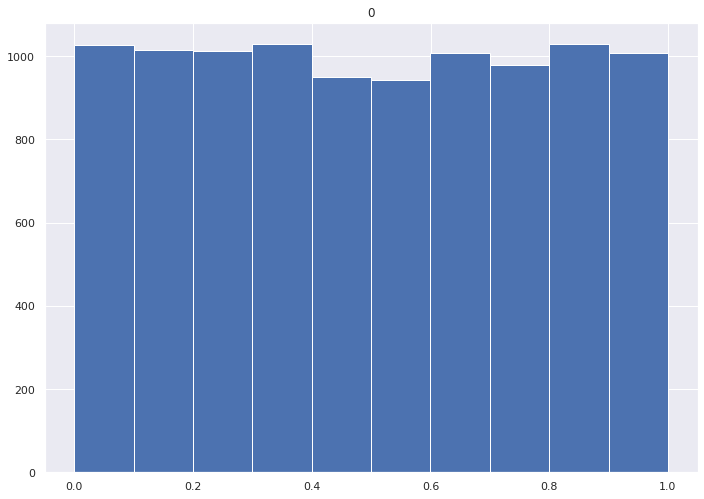

In [ ]:
t.hist()

p-value распределено равномерно

In [ ]:
(t<0.05).mean()

0    0.0506
dtype: float64

ошибка первого рода составляет 5 %, можем применять указанную систему сплитования для проведения А/B теста

Используются данные с курса "Симулятор аналитика" Karpov Courses (https://karpov.courses/simulator)